<a href="https://colab.research.google.com/github/pisceno/AI-Generative/blob/main/Segmentacion_clientes_16_05_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Clientes Segmentados ---
  Customer  Music_Streaming_Hours  Podcast_Listening_Hours  Cluster
3   Melody                     19                       50        0
4     Reed                      7                       44        0
5    Viola                     16                       52        0
6     Rock                      5                       19        1
7    Piper                     10                       11        1
8  Allegra                     17                        9        1
0     Aria                     46                        9        2
2  Harmony                     44                       17        2
1    Chord                     38                       10        2


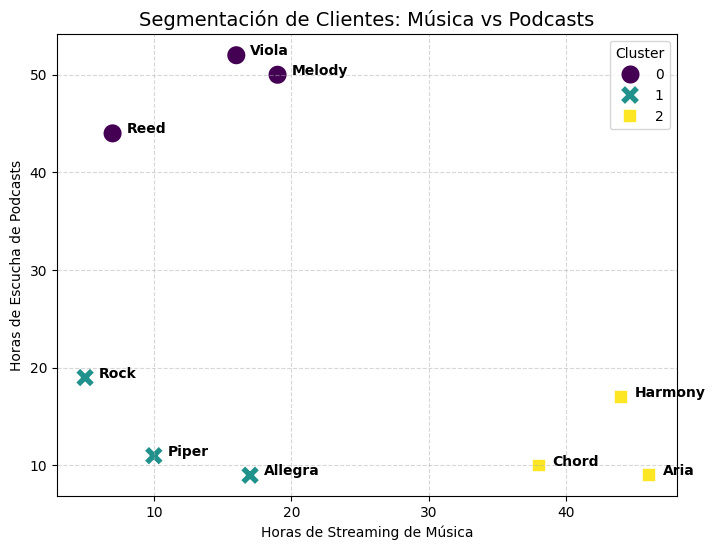

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Crear el dataset basado en tu imagen
data = {
    'Customer': ['Aria', 'Chord', 'Harmony', 'Melody', 'Reed', 'Viola', 'Rock', 'Piper', 'Allegra'],
    'Music_Streaming_Hours': [46, 38, 44, 19, 7, 16, 5, 10, 17],
    'Podcast_Listening_Hours': [9, 10, 17, 50, 44, 52, 19, 11, 9]
}

df = pd.DataFrame(data)

# 2. Seleccionar las variables numéricas para el modelo
X = df[['Music_Streaming_Hours', 'Podcast_Listening_Hours']]

# 3. Escalar los datos (Esencial para que K-Means funcione correctamente)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar el algoritmo K-Means (Buscamos 3 grupos)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Asignar nombres lógicos a los clusters basados en sus centroides
# (Nota: El orden de los números de cluster 0, 1, 2 puede variar según la ejecución)
print("--- Clientes Segmentados ---")
print(df.sort_values(by='Cluster'))

# 6. Graficar los resultados para presentación o análisis visual
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Music_Streaming_Hours',
    y='Podcast_Listening_Hours',
    hue='Cluster',
    palette='viridis',
    s=200,
    style='Cluster'
)

# Añadir las etiquetas de los nombres de los clientes en la gráfica
for i in range(df.shape[0]):
    plt.text(
        df.Music_Streaming_Hours[i] + 1,
        df.Podcast_Listening_Hours[i],
        df.Customer[i],
        horizontalalignment='left',
        size='medium',
        color='black',
        weight='semibold'
    )

plt.title('Segmentación de Clientes: Música vs Podcasts', fontsize=14)
plt.xlabel('Horas de Streaming de Música')
plt.ylabel('Horas de Escucha de Podcasts')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()